# 1) Setup

## Importing libraries, initializing constants, and reading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, classification_report

from xgboost import XGBClassifier

# Dictionary to label attack_detected
attack_label = {0: "Normal", 1: "Attack"}

# Consts
RANDOM_STATE = 29
TARGET_COLUMN = "attack_detected"

# Load data
data_path = Path("..")/"data"/"cybersecurity_intrusion_data.csv"
intrusion_df = pd.read_csv(data_path, keep_default_na=False) # Dataset has none as an actual field value, so keep it

## Declaring functions

In [2]:
def print_metrics(model, X_test, y_test):
    """Display model's metrics"""
    # Get model predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Get false negative rate 
    true_neg, false_pos, false_neg, true_pos = confusion_matrix(y_test, y_pred).ravel()
    false_negative_rate = false_neg / (false_neg + true_pos)

    # Get results from model's predictions
    results = pd.DataFrame([{
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "avg_precision": average_precision_score(y_test, y_prob),
        "false_negative_rate": false_negative_rate
    }])

    # Display a classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))
    print()

    # Display model metrics
    print("Metrics:")
    return results.round(3) # Needs to return to display


def plot_model_charts(model, X_test, y_test):
    """Creates 3 side by side plots of confustion matrix, AUC, and ROC"""
    # Get models predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Create 3 side by side plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Confusion Matrix
    confuse_matrix = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=confuse_matrix, display_labels=["Normal", "Attack"]).plot(ax=axes[0], cmap="Greens", colorbar=False)
    axes[0].set_title("Confusion Matrix")

    # ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
    axes[1].set_title("ROC Curve")
    
    # Precision Recall Curve
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2])
    axes[2].set_title("Precision Recall Curve")
    
    plt.show()

## Read first 5 rows and last 5 rows to data to ensure it loaded as expected

In [3]:
intrusion_df

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9532,SID_09533,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9533,SID_09534,380,TCP,3,182.848475,None,0.408485,0,Chrome,0,0
9534,SID_09535,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0
9535,SID_09536,406,TCP,4,86.664703,AES,0.537417,1,Chrome,1,0


## Check column information to gain insight

In [4]:
intrusion_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   str    
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   str    
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      9537 non-null   str    
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   str    
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 819.7 KB


## Look at stats of numerical data to gain insight

In [5]:
intrusion_df.describe().T

,count,mean,std,min,25%,50%,75%,max
network_packet_size,9537.0,500.430639,198.379364,64.000000,365.000000,499.000000,635.000000,1285.000000
login_attempts,9537.0,4.032086,1.963012,1.000000,3.000000,4.000000,5.000000,13.000000
session_duration,9537.0,792.745312,786.560144,0.500000,231.953006,556.277457,1105.380602,7190.392213
ip_reputation_score,9537.0,0.331338,0.177175,0.002497,0.191946,0.314778,0.453388,0.924299
failed_logins,9537.0,1.517773,1.033988,0.000000,1.000000,1.000000,2.000000,5.000000
unusual_time_access,9537.0,0.149942,0.357034,0.000000,0.000000,0.000000,0.000000,1.000000
attack_detected,9537.0,0.447101,0.497220,0.000000,0.000000,0.000000,1.000000,1.000000


##  Check for any missing values, duplicate rows, and how many normal vs attack there is

In [6]:
print("Missing values per column:")
print(f"{intrusion_df.isna().sum().sort_values(ascending=False)}")
print("\nDuplicate rows:", intrusion_df.duplicated().sum())
print()
intrusion_df["attack_detected"].map(attack_label).value_counts()

Missing values per column:
session_id             0
network_packet_size    0
protocol_type          0
login_attempts         0
session_duration       0
encryption_used        0
ip_reputation_score    0
failed_logins          0
browser_type           0
unusual_time_access    0
attack_detected        0
dtype: int64

Duplicate rows: 0



attack_detected
Normal    5273
Attack    4264
Name: count, dtype: int64

In [7]:
# Check for unrealistic rows where failed_logins > login_attempts

bad_rows = intrusion_df[intrusion_df["failed_logins"] > intrusion_df["login_attempts"]].copy()

print(f"Rows with failed_logins > login_attempts: {len(bad_rows)}")
print(f"Percent of dataset: {len(bad_rows) / len(intrusion_df):.2%}")
print()

print("Attack label breakdown for these rows:")
display(bad_rows["attack_detected"].map(attack_label).value_counts())

print("\nSample problematic rows:")
display(
    bad_rows[
        [
            "login_attempts",
            "failed_logins",
            "ip_reputation_score",
            "session_duration",
            "browser_type",
            "unusual_time_access",
            "attack_detected",
        ]
    ].head(15)
)


Rows with failed_logins > login_attempts: 730
Percent of dataset: 7.65%

Attack label breakdown for these rows:


attack_detected
Attack    516
Normal    214
Name: count, dtype: int64


Sample problematic rows:


,login_attempts,failed_logins,ip_reputation_score,session_duration,browser_type,unusual_time_access,attack_detected
17,1,2,0.136729,87.641002,Firefox,0,0
33,2,3,0.110269,1039.101186,Chrome,0,1
59,1,2,0.259419,989.889796,Edge,0,1
69,1,2,0.408654,1105.380602,Chrome,0,1
101,2,3,0.204681,294.584967,Chrome,0,1
104,1,2,0.209989,2505.190225,Chrome,0,0
130,1,2,0.324801,43.944500,Chrome,0,0
138,1,2,0.506077,1185.779775,Chrome,0,0
139,1,4,0.238039,897.990082,Unknown,0,1
141,1,2,0.177541,959.630016,Chrome,0,0


In [8]:
# Compare unrealistic rows to the rest of the dataset

intrusion_df["failed_gt_attempts"] = intrusion_df["failed_logins"] > intrusion_df["login_attempts"]

summary = intrusion_df.groupby("failed_gt_attempts").agg(
    rows=("attack_detected", "size"),
    attack_rate=("attack_detected", "mean"),
    avg_login_attempts=("login_attempts", "mean"),
    avg_failed_logins=("failed_logins", "mean"),
    avg_ip_reputation=("ip_reputation_score", "mean"),
)

display(summary.round(3))


,rows,attack_rate,avg_login_attempts,avg_failed_logins,avg_ip_reputation
failed_gt_attempts,,,,,
False,8807,0.426,4.240,1.406,0.332
True,730,0.707,1.522,2.860,0.328


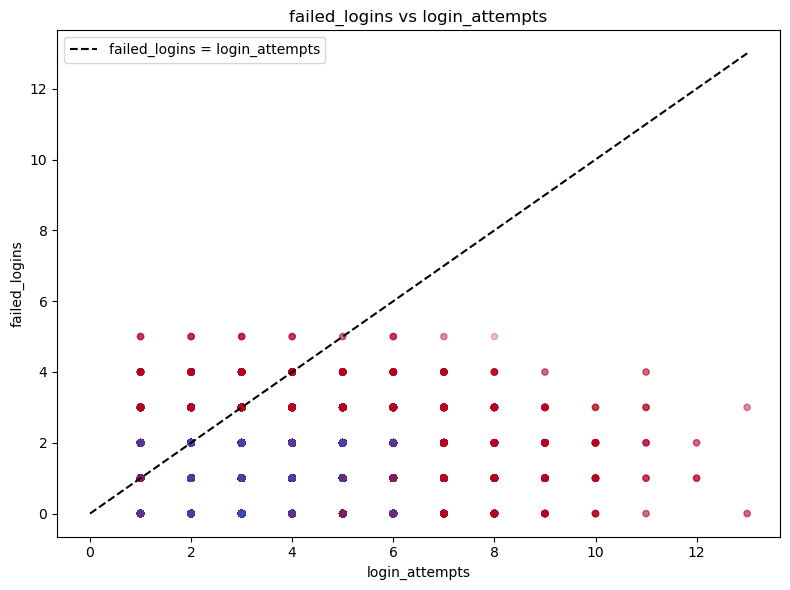

In [9]:
# Highlight rows where failed_logins > login_attempts

plt.figure(figsize=(8, 6))
plt.scatter(
    intrusion_df["login_attempts"],
    intrusion_df["failed_logins"],
    alpha=0.25,
    s=20,
    c=intrusion_df["attack_detected"],
    cmap="coolwarm"
)

max_val = max(intrusion_df["login_attempts"].max(), intrusion_df["failed_logins"].max())
plt.plot([0, max_val], [0, max_val], "k--", label="failed_logins = login_attempts")

plt.xlabel("login_attempts")
plt.ylabel("failed_logins")
plt.title("failed_logins vs login_attempts")
plt.legend()
plt.tight_layout()
plt.show()


# 2) Cleaning data

Here we will drop the `session_id` column as it only uniquely identifies each seesion but doesn't provide any data for the model to train on

In [10]:
# Drop session id column and check cols afterwards
intrusion_df = intrusion_df.drop(columns=["session_id"])

# Drop rows that have greater failed logins than login attempts
# fail_logins_greater_than_login_attempts = intrusion_df["failed_logins"] > intrusion_df["login_attempts"]
# print("Rows removed:", fail_logins_greater_than_login_attempts.sum())
# print("Percent data removed:", f"{fail_logins_greater_than_login_attempts.mean():.2%}")
# print()
# intrusion_df = intrusion_df.loc[intrusion_df["failed_logins"] <= intrusion_df["login_attempts"]].copy()

# Impute any failed login > attempt login with failed login = attempt login 
bad_mask = intrusion_df["failed_logins"] > intrusion_df["login_attempts"]
print("Rows adjusted:", bad_mask.sum())
print("Percent data adjusted:", f"{bad_mask.mean():.2%}")
print()
intrusion_df.loc[bad_mask, "failed_logins"] = intrusion_df.loc[bad_mask, "login_attempts"]


intrusion_df.info()
print()
print("New shape of data:", intrusion_df.shape)

Rows adjusted: 730
Percent data adjusted: 7.65%

<class 'pandas.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   network_packet_size  9537 non-null   int64  
 1   protocol_type        9537 non-null   str    
 2   login_attempts       9537 non-null   int64  
 3   session_duration     9537 non-null   float64
 4   encryption_used      9537 non-null   str    
 5   ip_reputation_score  9537 non-null   float64
 6   failed_logins        9537 non-null   int64  
 7   browser_type         9537 non-null   str    
 8   unusual_time_access  9537 non-null   int64  
 9   attack_detected      9537 non-null   int64  
 10  failed_gt_attempts   9537 non-null   bool   
dtypes: bool(1), float64(2), int64(5), str(3)
memory usage: 754.5 KB

New shape of data: (9537, 11)


## Feature Engineering

Here we will create some new features and modify existing features to find the most optimal features to train the model. We will pass the original dataset, but the function will only copy to create a new dataset with the new features

In [11]:
def feature_engineering(df):
    """Create a new features from current features"""

    new_df = df.copy()

    # New featured cols
    new_df["failed_login_ratio"] = new_df["failed_logins"] / new_df["login_attempts"].clip(lower=1)  # Avoid dividing by 0
    new_df["average_packet_rate"] = new_df["network_packet_size"] / new_df["session_duration"].clip(lower=0.0001) # Avoid dividing by 0
    new_df["login_risk_interaction"] = new_df["login_attempts"] * new_df["ip_reputation_score"]
    
    
    return new_df

new_df = feature_engineering(intrusion_df)
new_df

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected,failed_gt_attempts,failed_login_ratio,average_packet_rate,login_risk_interaction
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1,False,0.250000,1.215051,2.427272
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0,False,0.000000,0.302953,0.904707
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1,False,0.666667,8.381720,2.217493
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1,False,0.000000,1.337217,0.493069
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0,False,0.200000,0.850639,0.274369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9532,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1,False,1.000000,0.858218,1.553211
9533,380,TCP,3,182.848475,None,0.408485,0,Chrome,0,0,False,0.000000,2.078224,1.225456
9534,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0,False,0.200000,18.879594,1.796001
9535,406,TCP,4,86.664703,AES,0.537417,1,Chrome,1,0,False,0.250000,4.684722,2.149667


# 3) Train and Split data

Here we will create train and test data

In [12]:
# Create test and train sets
X = intrusion_df.drop(columns=[TARGET_COLUMN]).copy()
y = intrusion_df[TARGET_COLUMN].astype(int).copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=RANDOM_STATE, stratify=y,)

# Seperate numeric and categorial features
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

# Create a preprocessor to scale and one-hot encode features
preprocessor = ColumnTransformer(
                                transformers=[
                                              ("num", StandardScaler(), numeric_features), # "passthrough" for no scaling
                                              ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
                                             ]
                                )

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print("\nNumeric features:", numeric_features)
print("\nCategorical features:", categorical_features)
print()

Train shape: (8583, 10)
Test shape: (954, 10)

Numeric features: ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access']

Categorical features: ['protocol_type', 'encryption_used', 'browser_type', 'failed_gt_attempts']



## Models to train and test

In [13]:
models = {
    "Perceptron": Perceptron(random_state=RANDOM_STATE),
    "LogisticRegression": LogisticRegression(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=25),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost" : XGBClassifier(random_state=RANDOM_STATE)
}
print("Models to compare:")
for name in models:
    print("-", name)

Models to compare:
- Perceptron
- LogisticRegression
- KNN
- RandomForest
- GradientBoosting
- HistGradientBoosting
- XGBoost


## Cross validate each model
For each model we create a pipline that is the preprocessor and model that uses cross validate to use stratifiedKfold to fit the models and score on each fold. Then it'll average the scores and show how the models performed

In [14]:
# Set up stratified K-fold cross validation
cross_validation = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# Scores to keep track of after fitting model
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

model_pipelines = {}
model_results = []

for name, model in models.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
    model_pipelines[name] = pipeline  # Save pipeline under model's name

    # Fit and get scores from model
    cross_validation_scores = cross_validate(pipeline, X_train, y_train, cv=cross_validation, scoring=scoring)

    # Get a score summary for each model 
    model_summary = {"model": name}
    for metric_name in scoring:
        model_summary[f"{metric_name}_mean"] = cross_validation_scores[f"test_{metric_name}"].mean()
    for metric_name in scoring:
        model_summary[f"{metric_name}_std"] = cross_validation_scores[f"test_{metric_name}"].std()
    model_results.append(model_summary)

# Sort results by f1_mean and display 
cv_results = pd.DataFrame(model_results).sort_values(by="f1_mean", ascending=False).reset_index(drop=True)
cv_results.round(2)


,model,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,accuracy_std,precision_std,recall_std,f1_std,roc_auc_std
0,HistGradientBoosting,0.88,0.97,0.75,0.85,0.88,0.01,0.01,0.02,0.02,0.01
1,RandomForest,0.88,0.97,0.75,0.85,0.88,0.01,0.01,0.02,0.01,0.01
2,GradientBoosting,0.88,0.98,0.74,0.84,0.88,0.01,0.01,0.02,0.01,0.01
3,XGBoost,0.87,0.95,0.76,0.84,0.88,0.01,0.01,0.02,0.01,0.01
4,KNN,0.81,0.94,0.62,0.75,0.86,0.01,0.01,0.02,0.02,0.01
5,LogisticRegression,0.75,0.73,0.68,0.71,0.81,0.02,0.03,0.03,0.03,0.02
6,Perceptron,0.68,0.65,0.66,0.64,0.75,0.04,0.07,0.13,0.04,0.03


- The top 4 models appear to be GradientBoosting, RandomForest, HistGradientBoosting, and XGBoost. All are very similiar with subtle difference, but XGBoost does hight a 0.01 higher in recall than the others which makes it a good candidate to further look into
  

# GradientBoosting 
Here we will fit the model and evaluate how it does on the test set.

Description of metrics:  
- Accuracy
  - Overall Percent correct
- Precision
  - Of everything predicted as __Attack__, how many were actual attacks?
    - Higher Precision = less false alarms
- Recall
  - Of all --actual attacks--, how many did the model catch?
    - High Recall = less attacks slipping through the cracks
- F1
  - Balance between precision and recall
- ROC AUC
  - How well the model seperates normal from attack
    - Higher the better
- False Negative Rate
  - Of all actual attacks, how many were missed?  

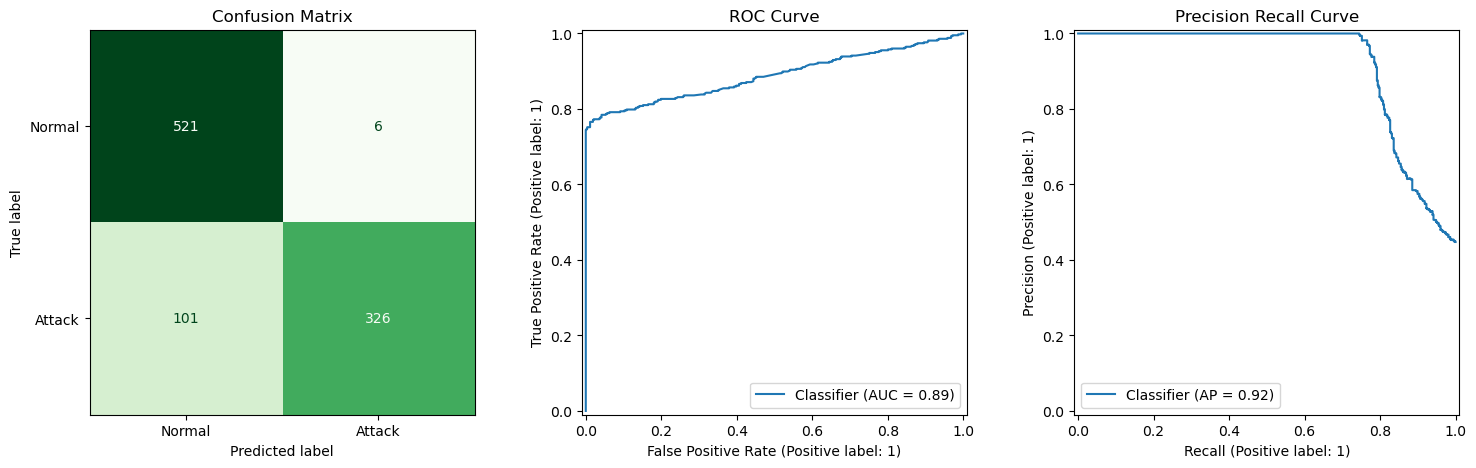

Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.99      0.91       527
      Attack       0.98      0.76      0.86       427

    accuracy                           0.89       954
   macro avg       0.91      0.88      0.88       954
weighted avg       0.90      0.89      0.89       954


Metrics:


,accuracy,precision,recall,f1,roc_auc,avg_precision,false_negative_rate
0,0.888,0.982,0.763,0.859,0.888,0.916,0.237


In [15]:
# Get GradientBoost Model pipeline and fit it. Pipeline handles preprocessing data the same as before
GradientBoosting_model = model_pipelines["GradientBoosting"]
GradientBoosting_model.fit(X_train, y_train)

# Display model's metrics and plot charts
plot_model_charts(GradientBoosting_model, X_test, y_test)
print_metrics(GradientBoosting_model, X_test, y_test)

# Random Forest

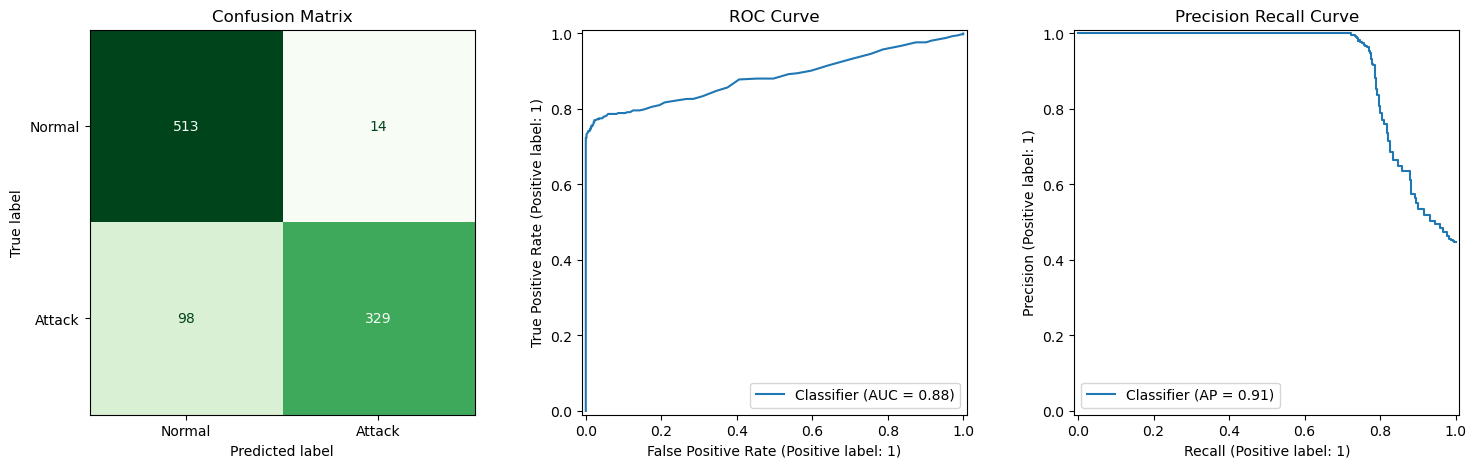

Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.97      0.90       527
      Attack       0.96      0.77      0.85       427

    accuracy                           0.88       954
   macro avg       0.90      0.87      0.88       954
weighted avg       0.89      0.88      0.88       954


Metrics:


,accuracy,precision,recall,f1,roc_auc,avg_precision,false_negative_rate
0,0.883,0.959,0.77,0.855,0.884,0.912,0.23


In [16]:
# Get RandomForest Model pipeline and fit it. Pipeline handles preprocessing data the same as before
RandomForest_model = model_pipelines["RandomForest"]
RandomForest_model.fit(X_train, y_train)

# Display model's metrics and plot charts
plot_model_charts(RandomForest_model, X_test, y_test)
print_metrics(RandomForest_model, X_test, y_test)

# HistGradientBoosting

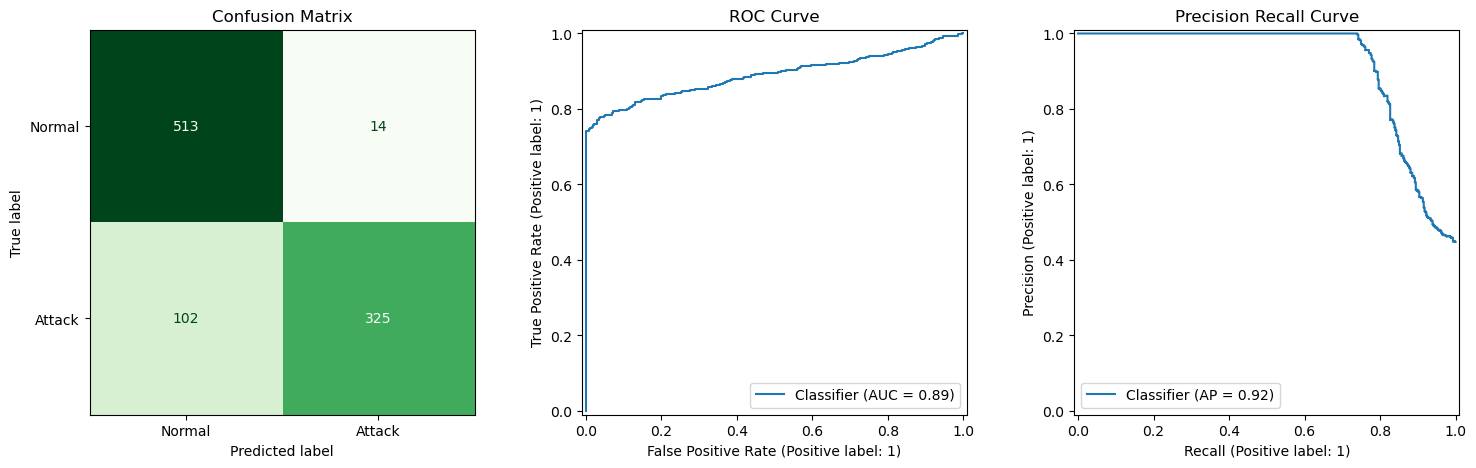

Classification Report:
              precision    recall  f1-score   support

      Normal       0.83      0.97      0.90       527
      Attack       0.96      0.76      0.85       427

    accuracy                           0.88       954
   macro avg       0.90      0.87      0.87       954
weighted avg       0.89      0.88      0.88       954


Metrics:


,accuracy,precision,recall,f1,roc_auc,avg_precision,false_negative_rate
0,0.878,0.959,0.761,0.849,0.89,0.918,0.239


In [17]:
# Get HistGradientBoosting Model pipeline and fit it. Pipeline handles preprocessing data the same as before
HistGradientBoosting_model = model_pipelines["HistGradientBoosting"]
HistGradientBoosting_model.fit(X_train, y_train)

# Display model's metrics and plot charts
plot_model_charts(HistGradientBoosting_model, X_test, y_test)
print_metrics(HistGradientBoosting_model, X_test, y_test)

# XGBoost

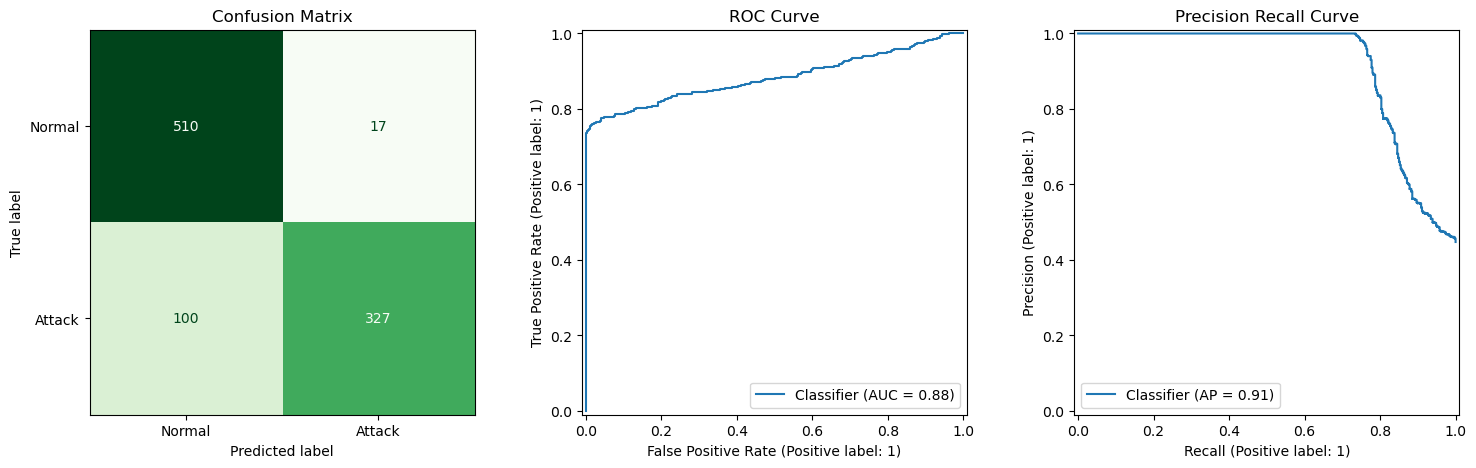

Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.97      0.90       527
      Attack       0.95      0.77      0.85       427

    accuracy                           0.88       954
   macro avg       0.89      0.87      0.87       954
weighted avg       0.89      0.88      0.88       954


Metrics:


,accuracy,precision,recall,f1,roc_auc,avg_precision,false_negative_rate
0,0.877,0.951,0.766,0.848,0.883,0.913,0.234


In [18]:
# Get XGBoost Model pipeline and fit it. Pipeline handles preprocessing data the same as before
XGBoost_model = model_pipelines["XGBoost"]
XGBoost_model.fit(X_train, y_train)

# Display model's metrics and plot charts
plot_model_charts(XGBoost_model, X_test, y_test)
print_metrics(XGBoost_model, X_test, y_test)

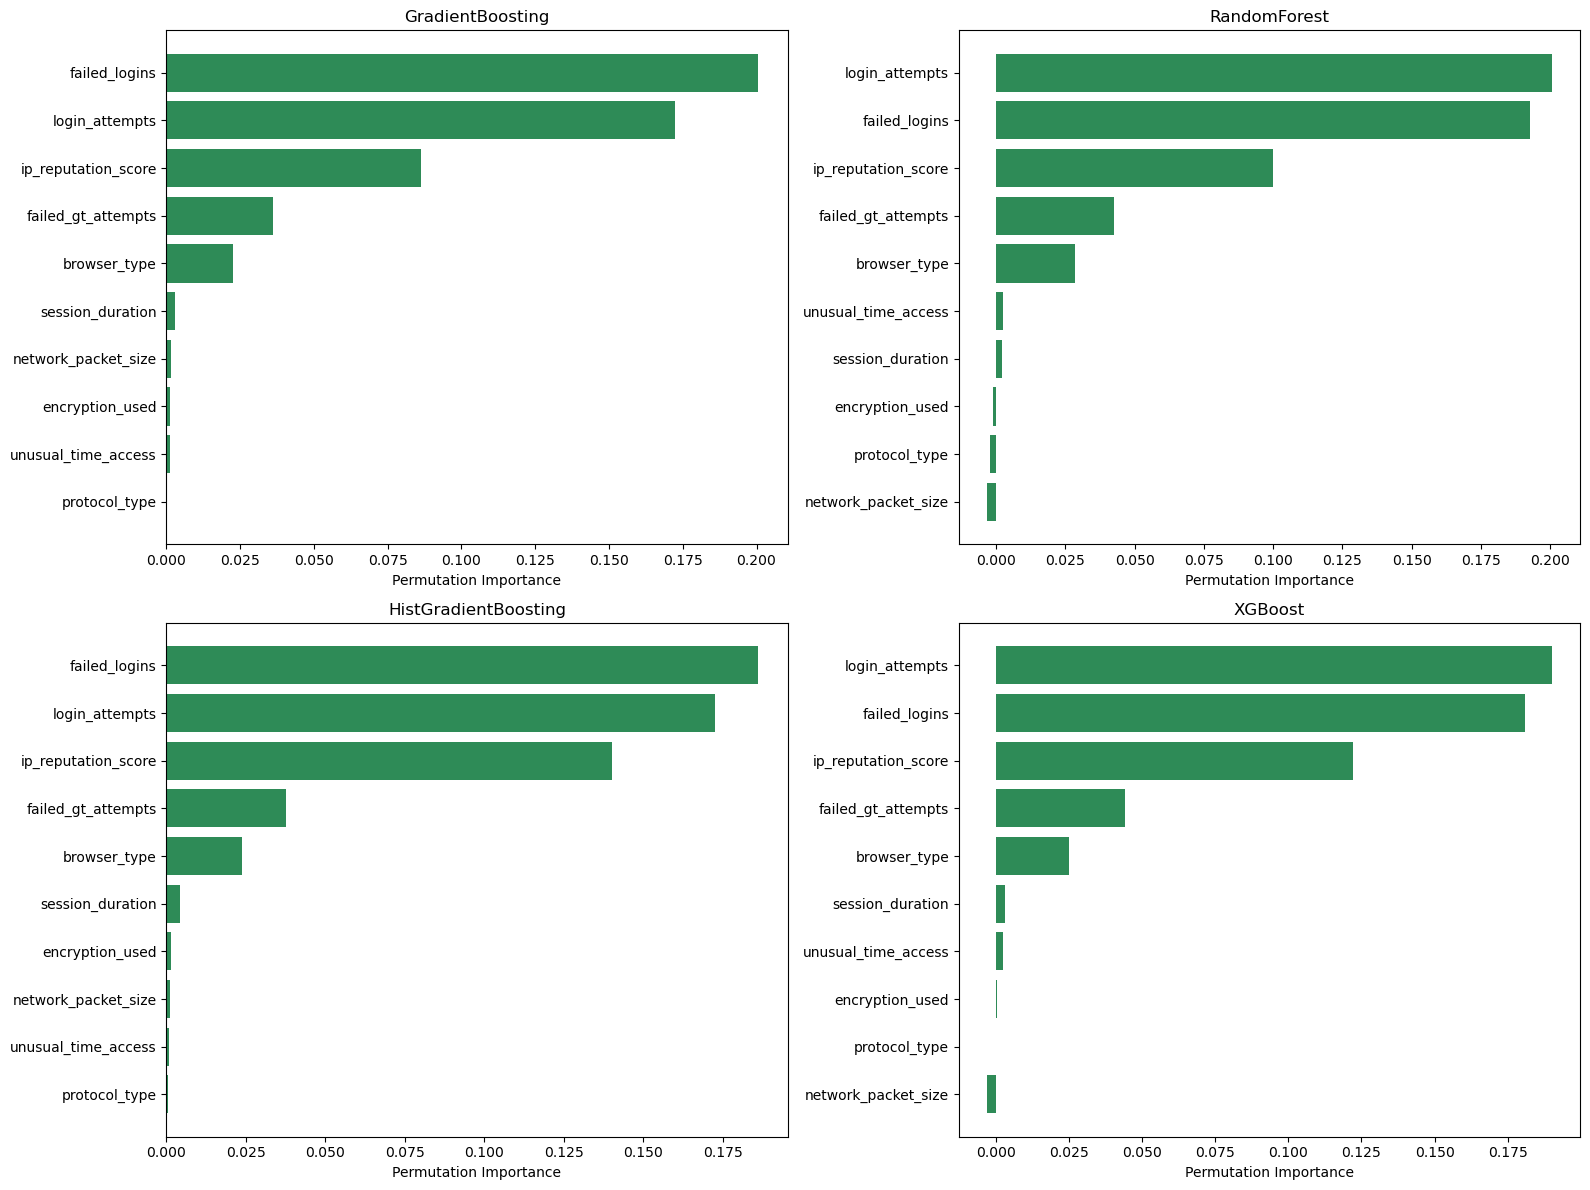


Top features for GradientBoosting:


,feature,importance
0,failed_logins,0.2005
1,login_attempts,0.1724
2,ip_reputation_score,0.0864
3,failed_gt_attempts,0.0362
4,browser_type,0.0225
5,session_duration,0.0031
6,network_packet_size,0.0017
7,encryption_used,0.0014
8,unusual_time_access,0.0012
9,protocol_type,0.0000



Top features for RandomForest:


,feature,importance
0,login_attempts,0.2005
1,failed_logins,0.1928
2,ip_reputation_score,0.0998
3,failed_gt_attempts,0.0426
4,browser_type,0.0283
5,unusual_time_access,0.0025
6,session_duration,0.0020
7,encryption_used,-0.0010
8,protocol_type,-0.0021
9,network_packet_size,-0.0032



Top features for HistGradientBoosting:


,feature,importance
0,failed_logins,0.1860
1,login_attempts,0.1726
2,ip_reputation_score,0.1403
3,failed_gt_attempts,0.0375
4,browser_type,0.0237
5,session_duration,0.0044
6,encryption_used,0.0015
7,network_packet_size,0.0011
8,unusual_time_access,0.0009
9,protocol_type,0.0005



Top features for XGBoost:


,feature,importance
0,login_attempts,0.1900
1,failed_logins,0.1809
2,ip_reputation_score,0.1221
3,failed_gt_attempts,0.0441
4,browser_type,0.0249
5,session_duration,0.0031
6,unusual_time_access,0.0024
7,encryption_used,0.0006
8,protocol_type,0.0001
9,network_packet_size,-0.0029


In [19]:
from sklearn.inspection import permutation_importance

top_4_models = {
    "GradientBoosting": GradientBoosting_model,
    "RandomForest": RandomForest_model,
    "HistGradientBoosting": HistGradientBoosting_model,
    "XGBoost": XGBoost_model,
}

importance_tables = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for ax, (model_name, model) in zip(axes, top_4_models.items()):
    result = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=15,
        random_state=RANDOM_STATE,
        scoring="average_precision",
        n_jobs=1,
    )

    importance_df = (
        pd.DataFrame({
            "feature": X_test.columns,
            "importance": result.importances_mean,
        })
        .sort_values("importance", ascending=False)
        .head(10)
        .sort_values("importance", ascending=True)
    )

    importance_tables[model_name] = importance_df.sort_values("importance", ascending=False)

    ax.barh(importance_df["feature"], importance_df["importance"], color="seagreen")
    ax.set_title(model_name)
    ax.set_xlabel("Permutation Importance")

plt.tight_layout()
plt.show()

for model_name, importance_df in importance_tables.items():
    print(f"\nTop features for {model_name}:")
    display(importance_df.reset_index(drop=True).round(4))